In [3]:
import h5py
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
with h5py.File('/nas/stage3_forecast/new_grid/cosmo_000002/perm_0000/projected_probes_maps_nobaryons512.h5', 'r') as f:
    kg = np.array(f['kg/stage3_lensing1'])
    dg = np.array(f['dg/stage3_lensing1'])
    ia = np.array(f['ia/stage3_lensing1'])

with h5py.File('/nas/stage3_forecast/new_grid/cosmo_000001/perm_0000/projected_probes_maps_nobaryons512.h5', 'r') as f:
    kg1 = np.array(f['kg/stage3_lensing1'])
    dg1 = np.array(f['dg/stage3_lensing1'])
    ia1 = np.array(f['ia/stage3_lensing1'])

In [55]:
def add_shape_noise(kg, sigma_e=0.26, galaxy_density=6.75, nside=512):
    """
    Adds shape noise to a full-sky Healpix convergence (kappa) map.
    """
    npix = hp.nside2npix(nside)
    pixel_area_arcmin2 = hp.nside2pixarea(nside, degrees=True) * 3600
    sigma_pix = sigma_e / np.sqrt(galaxy_density * pixel_area_arcmin2)
    noise = np.random.normal(loc=0, scale=sigma_pix, size=npix)
    return kg + noise

kg = add_shape_noise(kg)
kg1 = add_shape_noise(kg1)

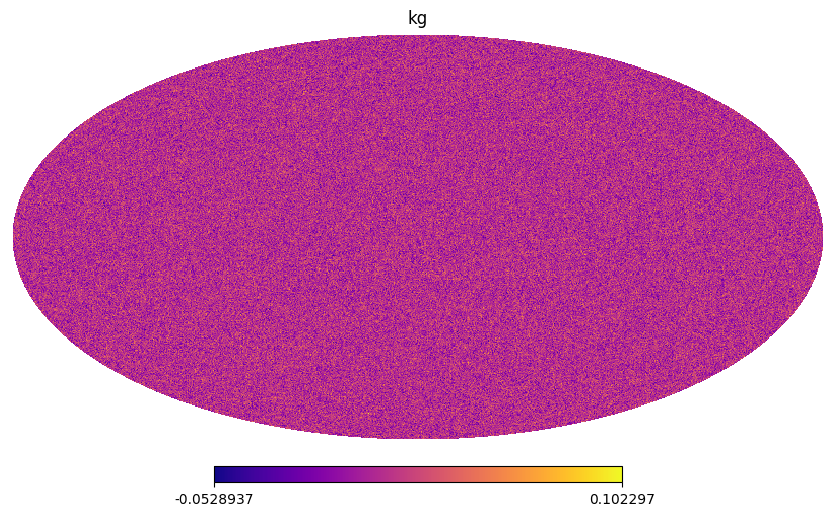

In [56]:
hp.mollview(kg, cmap='plasma', title='kg')

In [57]:
def scale_cls(c):
    ells = np.arange(len(c))
    return ells, ells*(ells+1)*c/(np.pi*2)

In [58]:
cls_kg = hp.alm2cl(hp.map2alm(kg, lmax=1024))
cls_kg1 = hp.alm2cl(hp.map2alm(kg1, lmax=1024))

In [59]:
hp.alm2cl(hp.map2alm(kg))

array([1.80087827e-03, 3.72813636e-09, 1.53719685e-08, ...,
       8.72391217e-10, 8.29373320e-10, 8.91103814e-10], shape=(1536,))

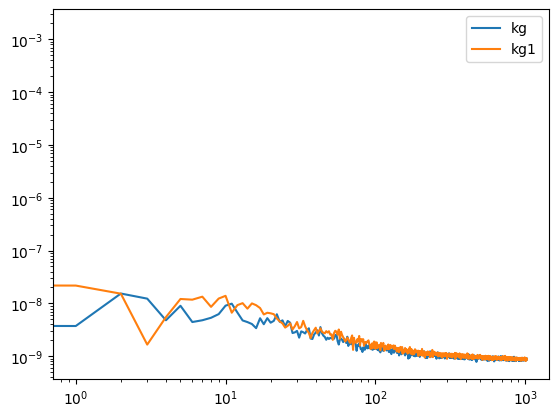

In [60]:
plt.loglog(cls_kg, label='kg')
plt.loglog(cls_kg1, label='kg1')
plt.legend()

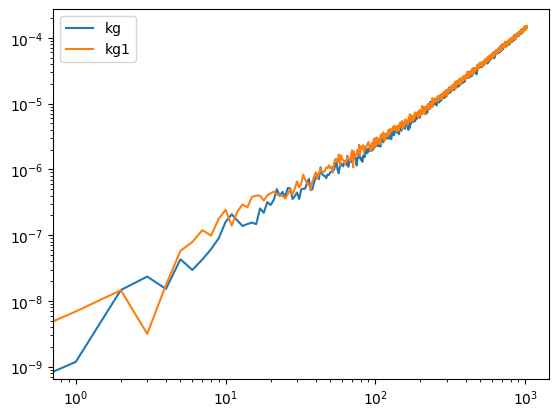

In [61]:
plt.loglog(*scale_cls(cls_kg), label='kg')
plt.loglog(*scale_cls(cls_kg1), label='kg1')
plt.legend()

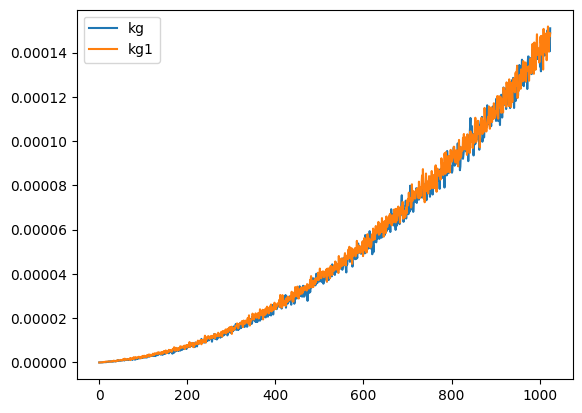

In [62]:
plt.plot(*scale_cls(cls_kg), label='kg')
plt.plot(*scale_cls(cls_kg1), label='kg1')
plt.legend()

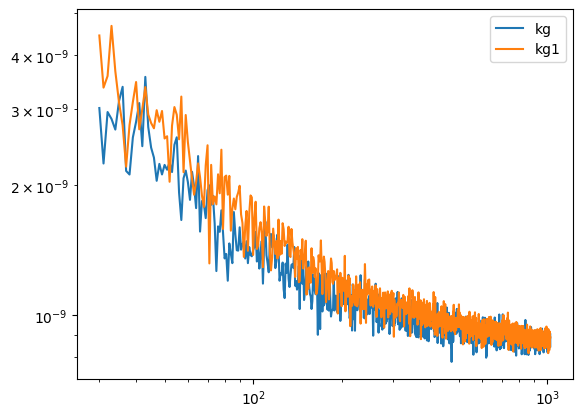

In [63]:
# ell cuts
def ell_cut(cls, ell_min=30, ell_max=1024):
    ells = np.arange(len(cls))
    mask = (ells >= ell_min) & (ells <= ell_max)
    return ells[mask], cls[mask]

plt.loglog(*ell_cut(cls_kg), label='kg')
plt.loglog(*ell_cut(cls_kg1), label='kg1')
plt.legend()


In [64]:
_, cls_kg_cut = ell_cut(cls_kg)
_, cls_kg1_cut = ell_cut(cls_kg1)

In [65]:
cls_kg_cut.shape

(995,)

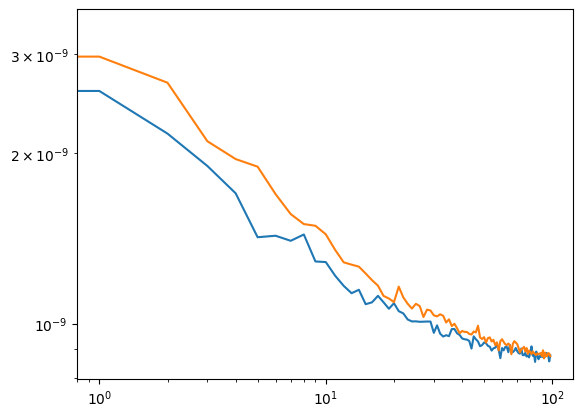

In [66]:
# rebin the cls_kg_cut and cls_kg1_cut
def rebin_cls(cls, factor=2):
    n = len(cls) // factor
    cls_rebinned = np.zeros(n)
    for i in range(n):
        cls_rebinned[i] = np.mean(cls[i*factor:(i+1)*factor])
    return cls_rebinned

cls_kg_cut_rebinned = rebin_cls(cls_kg_cut, factor=10)
cls_kg1_cut_rebinned = rebin_cls(cls_kg1_cut, factor=10)

plt.loglog(cls_kg_cut_rebinned, label='kg_rebinned')
plt.loglog(cls_kg1_cut_rebinned, label='kg1_rebinned')

In [37]:
cls_kg_cut_rebinned.shape

(99,)

## Full

### Load saved Cls (fid)

In [5]:
all_cls = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_nobaryons_bin2_noisy_s0.26.npy', allow_pickle=True)

In [6]:
all_cls

array([[9.79729711e-04, 2.34582734e-09, 1.62745001e-09, ...,
        1.68215477e-09, 1.73867483e-09, 1.64127730e-09],
       [9.80951780e-04, 1.40993481e-09, 4.92744279e-09, ...,
        1.76855176e-09, 1.73269571e-09, 1.66017646e-09],
       [9.84997030e-04, 1.61252605e-09, 2.26016668e-09, ...,
        1.70530643e-09, 1.66927891e-09, 1.75449625e-09],
       ...,
       [9.86760182e-04, 6.97307679e-09, 3.09678214e-09, ...,
        1.62767092e-09, 1.69919504e-09, 1.75350631e-09],
       [9.76444712e-04, 2.68398329e-09, 8.03356500e-10, ...,
        1.59934542e-09, 1.69736777e-09, 1.69551876e-09],
       [9.77838550e-04, 1.79600831e-09, 2.57815355e-09, ...,
        1.71206836e-09, 1.61649733e-09, 1.61039899e-09]],
      shape=(200, 1025))

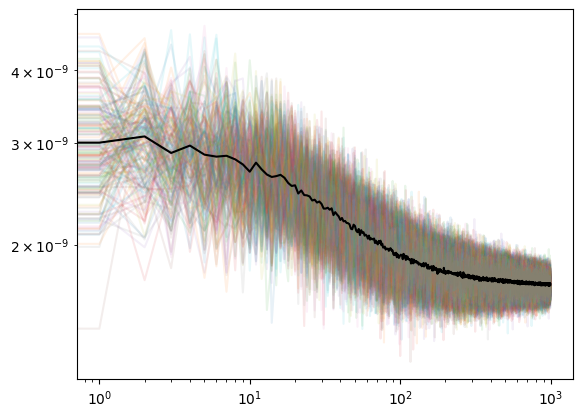

In [7]:
for i in all_cls:
    plt.loglog(i[30:], alpha=0.1)
plt.loglog(np.mean(all_cls, axis=0)[30:], label='mean', color='black')

### Load saved Cls (grid)

In [2]:
all_cls_grid = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/all_bnt_cls_grid_nobaryons_bin2_noisy_s0.26.npy', allow_pickle=True)

In [3]:
all_cls_grid

array([[1.36493889e-03, 8.96001625e-10, 3.18266732e-09, ...,
        1.75855535e-09, 1.82891956e-09, 1.69034467e-09],
       [1.36027206e-03, 4.68067463e-09, 4.60170106e-09, ...,
        1.73717486e-09, 1.66927484e-09, 1.78444383e-09],
       [1.36533354e-03, 5.08583359e-09, 5.42260732e-09, ...,
        1.72264802e-09, 1.74712066e-09, 1.82098985e-09],
       ...,
       [1.64814414e-03, 4.96489074e-10, 2.36543400e-09, ...,
        1.70182083e-09, 1.77683356e-09, 1.86690553e-09],
       [1.65190367e-03, 1.77775676e-09, 3.77975277e-10, ...,
        1.78539047e-09, 1.66865504e-09, 1.69841962e-09],
       [1.64812309e-03, 3.77661937e-09, 2.63482161e-09, ...,
        1.73522522e-09, 1.80203051e-09, 1.77180288e-09]],
      shape=(16965, 1025))

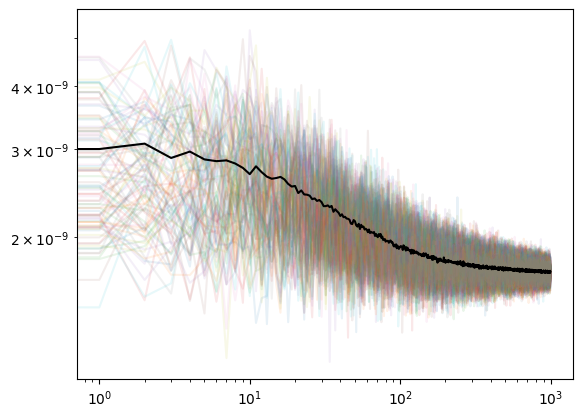

In [8]:
for i in all_cls_grid[:100]:
    plt.loglog(i[30:], alpha=0.1)
plt.loglog(np.mean(all_cls, axis=0)[30:], label='mean', color='black')

In [ ]:
for i in all_cls_grid[:1000]:
    plt.loglog(rebin_cls(i[30:], factor=10), alpha=0.4)
plt.loglog(rebin_cls(np.mean(all_cls_grid, axis=0)[30:], factor=10), label='mean', color='black')
# plt.loglog(np.mean(all_cls, axis=0)[30:], label='mean', color='black')

## BNT vs noBNT

### Load saved Cls (fid)

In [7]:
all_cls = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_cls_fiducial_nobaryons_bin4_noisy_s0.26.npy', allow_pickle=True)
all_cls_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_cls_fiducial_nobaryons_bin4_noisy_s0.26.npy', allow_pickle=True)

In [ ]:
all_cls.shape, all_cls_bnt.shape

((200, 1025), (200, 1025))

: 

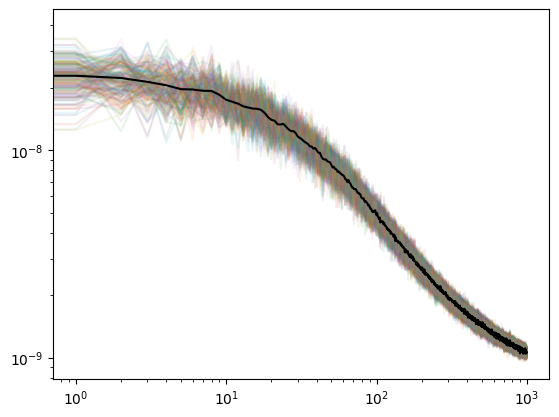

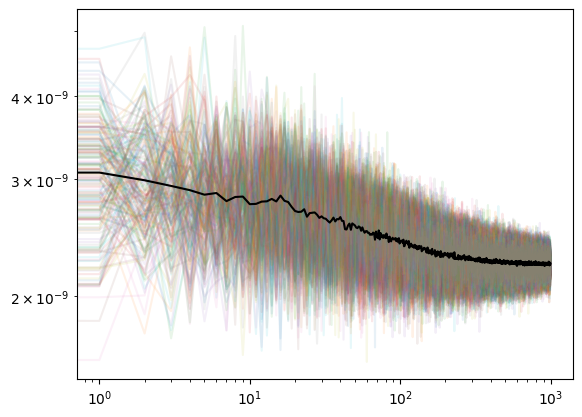

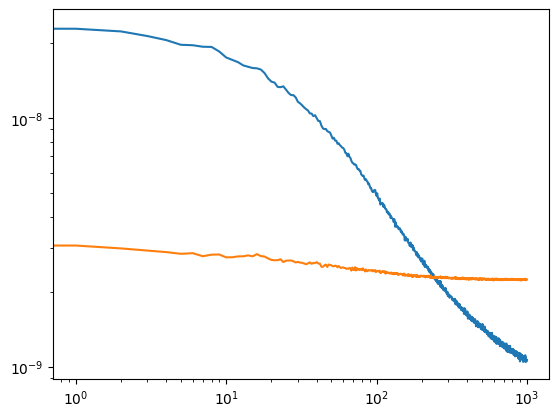

In [8]:
for i in all_cls:
    plt.loglog(i[30:], alpha=0.1)
plt.loglog(np.mean(all_cls, axis=0)[30:], label='mean', color='black')
plt.show()

for i in all_cls_bnt:
    plt.loglog(i[30:], alpha=0.1)
plt.loglog(np.mean(all_cls_bnt, axis=0)[30:], label='mean', color='black')
plt.show()

plt.loglog(np.mean(all_cls, axis=0)[30:], label='noBNT')
plt.loglog(np.mean(all_cls_bnt, axis=0)[30:], label='BNT')
plt.show()

### Load saved Cls (grid)

In [ ]:
all_cls_grid = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/all_cls_grid_nobaryons_bin1_noisy_s0.26.npy', allow_pickle=True)
all_cls_grid_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/all_bnt_cls_grid_nobaryons_bin1_noisy_s0.26.npy', allow_pickle=True)

In [ ]:
all_cls_grid.shape, all_cls_grid_bnt.shape

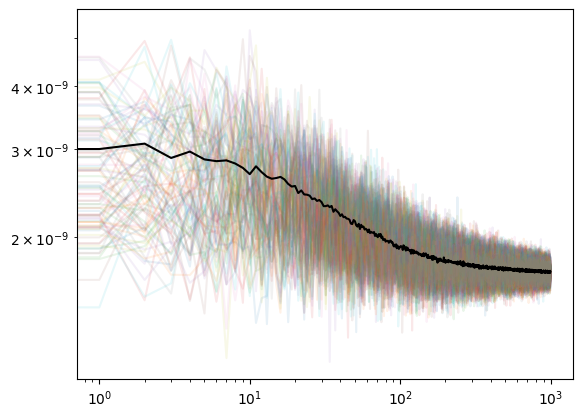

In [ ]:
for i in all_cls_grid[:100]:
    plt.loglog(i[30:], alpha=0.1)
plt.loglog(np.mean(all_cls, axis=0)[30:], label='mean', color='black')

In [ ]:
for i in all_cls_grid[:1000]:
    plt.loglog(rebin_cls(i[30:], factor=10), alpha=0.4)
plt.loglog(rebin_cls(np.mean(all_cls_grid, axis=0)[30:], factor=10), label='mean', color='black')
# plt.loglog(np.mean(all_cls, axis=0)[30:], label='mean', color='black')